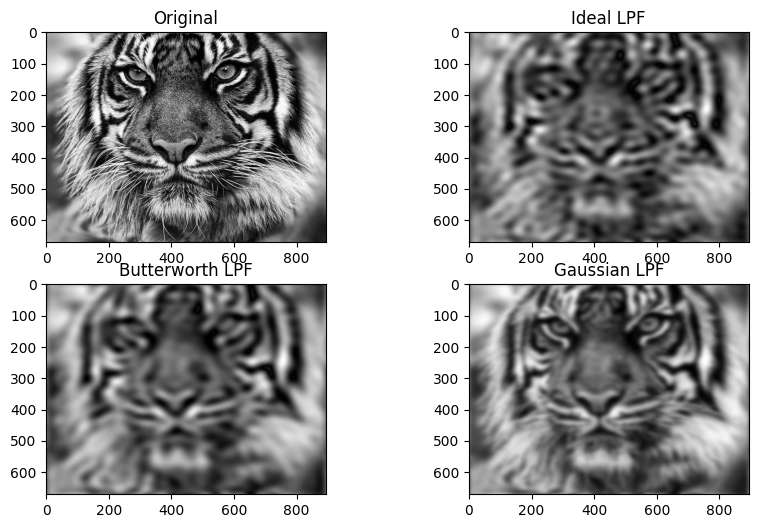

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("image.jpg",0)

# FFT
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

rows, cols = img.shape
crow, ccol = rows//2 , cols//2

D0 = 20
n = 5

# Create masks
ILPF = np.zeros((rows,cols))
BLPF = np.zeros((rows,cols))
GLPF = np.zeros((rows,cols))

for i in range(rows):
    for j in range(cols):

        D = np.sqrt((i-crow)**2 + (j-ccol)**2)

        # Ideal LPF
        if D <= D0:
            ILPF[i,j] = 1

        # Butterworth LPF
        BLPF[i,j] = 1/(1+(D/D0)**(2*n))

        # Gaussian LPF
        GLPF[i,j] = np.exp(-(D**2)/(2*(D0**2)))

# Apply filters
ideal = fshift * ILPF
butter = fshift * BLPF
gauss = fshift * GLPF

# Inverse FFT
ideal_img = np.abs(np.fft.ifft2(np.fft.ifftshift(ideal)))
butter_img = np.abs(np.fft.ifft2(np.fft.ifftshift(butter)))
gauss_img = np.abs(np.fft.ifft2(np.fft.ifftshift(gauss)))

# Display results
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(img,cmap='gray')

plt.subplot(2,2,2)
plt.title("Ideal LPF")
plt.imshow(ideal_img,cmap='gray')

plt.subplot(2,2,3)
plt.title("Butterworth LPF")
plt.imshow(butter_img,cmap='gray')

plt.subplot(2,2,4)
plt.title("Gaussian LPF")
plt.imshow(gauss_img,cmap='gray')

plt.show()